<a href="https://colab.research.google.com/github/milleau98/2026-gig-data-analysis/blob/main/notebooks/data-analyses/correlation_analyses.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
!pip install -q pandas numpy matplotlib scipy seaborn

In [35]:
import os
from getpass import getpass

TOKEN = getpass('Enter GitHub token: ')
REPO = "milleau98/2026-gig-data-analysis"

if not os.path.exists("2026-gig-data-analysis"):
    !git clone https://{TOKEN}@github.com/{REPO}.git
else:
    %cd 2026-gig-data-analysis
    !git pull

Enter GitHub token: ··········
Cloning into '2026-gig-data-analysis'...
remote: Enumerating objects: 609, done.
remote: Counting objects: 100% (166/166), done.
remote: Compressing objects: 100% (129/129), done.
remote: Total 609 (delta 102), reused 46 (delta 37), pack-reused 443 (from 1)
Receiving objects: 100% (609/609), 35.47 MiB | 11.98 MiB/s, done.
Resolving deltas: 100% (295/295), done.


In [36]:
import os

os.listdir()

['data',
 'notebooks',
 '.git',
 '2026-gig-data-analysis',
 'README.md',
 'google_trends.ipynb',
 '.gitignore']

In [37]:
os.listdir('2026-gig-data-analysis')

['data', 'notebooks', '.git', 'README.md', 'google_trends.ipynb', '.gitignore']

In [38]:
os.listdir('2026-gig-data-analysis/data')

['google_trends', 'fred', 'final', 'yfinance']

In [39]:
import pandas as pd

# stock price

gig_stock_df_monthly = pd.read_csv('2026-gig-data-analysis/data/yfinance/gig_yfinance_monthly.csv', parse_dates=['Date'])

sp500_stock_df_monthly = pd.read_csv('2026-gig-data-analysis/data/yfinance/sp500_yfinance_monthly.csv', parse_dates=['Date'])

# Combine gig and sp500 stock data

stock_df_monthly = pd.concat([gig_stock_df_monthly, sp500_stock_df_monthly])


# google trend data

google_df_monthly = pd.read_csv('2026-gig-data-analysis/data/google_trends/google_trends_monthly.csv', parse_dates=['date'])

# FRED data

fred_df_monthly = pd.read_csv('2026-gig-data-analysis/data/fred/fred_monthly_data.csv', parse_dates=['date'])


stock_df_monthly.head()
fred_df_monthly.head()



,date,month,quarter,year,interest_rate_mtg_data_weekly,cpi_data_monthly,cpi_fesl_data_monthly,rec_sahm_data_monthly,rec_smooth_prob_data_monthly,rec_nber_data_monthly,...,consumer_sentiment_composite_amplitude_data_monthly,job_openings_data_monthly,job_hires_data_monthly,job_separations_data_monthly,average_weekly_earnings_data_monthly,gdp_data_quarterly,gdp_real_data_quarterly,cpi_inflation_data_annual,median_income_real_data_annual,median_income_data_annual
0,1854-12-01,12,4,1854,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1855-01-01,1,1,1855,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1855-02-01,2,1,1855,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1855-03-01,3,1,1855,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1855-04-01,4,2,1855,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
google_df_monthly_long = google_df_monthly.melt(
    id_vars=['year', 'month'],
    value_vars= ['Uber','Lyft','DoorDash','Instacart','Fiverr','Upwork', 'Nu skin', 'USANA', 'side hustle','gig','Herbalife','Primerica','Etsy', 'Shopify', 'Udemy'],
    var_name = 'company',
    value_name = 'SearchInterest'
)


In [41]:
# rename columns to match across datasets
gig_stock_df_monthly = gig_stock_df_monthly.rename(columns={'Year': 'year'})
sp500_stock_df_monthly = sp500_stock_df_monthly.rename(columns={'Year': 'year'})

stock_df_monthly = stock_df_monthly.rename(columns={'Year':'year', 'Month':'month', 'Company':'company'})

gig_stock_df_monthly = gig_stock_df_monthly.rename(columns={'Month': 'month'})
sp500_stock_df_monthly = sp500_stock_df_monthly.rename(columns={'Month': 'month'})

# only keep necessary columns before merging
monthly_stock_cols = ['year', 'month', 'company','Close']
monthly_fred_cols = ['year', 'month', 'cpi_inflation_data_annual','unemployment_data_monthly', 'cpi_data_monthly', 'rec_smooth_prob_data_monthly', 'rec_nber_data_monthly',
                     'labor_force_participation_data_monthly', 'job_hires_data_monthly', 'gdp_real_data_quarterly', 'm2_real_data_monthly', 'interest_rate_fedfunds_data_monthly',
                     'consumer_sentiment_data_monthly']

stock_df_monthly = stock_df_monthly[monthly_stock_cols]

fred_df_monthly = fred_df_monthly[monthly_fred_cols]

# Create target variable = close/cpi_data_monthly

google_df_monthly_long = google_df_monthly_long[['year', 'month', 'company','SearchInterest']]

merged_df_monthly = (
    stock_df_monthly
    .merge(google_df_monthly_long, on=['year','company','month'], how='left')
    .merge(fred_df_monthly, on=['year','month'], how='left'))

# Create target variable = close/cpi_data_monthly

merged_df_monthly['target'] = merged_df_monthly['Close'] / merged_df_monthly['cpi_data_monthly']

merged_df_monthly.head(75)

,year,month,company,Close,SearchInterest,cpi_inflation_data_annual,unemployment_data_monthly,cpi_data_monthly,rec_smooth_prob_data_monthly,rec_nber_data_monthly,labor_force_participation_data_monthly,job_hires_data_monthly,gdp_real_data_quarterly,m2_real_data_monthly,interest_rate_fedfunds_data_monthly,consumer_sentiment_data_monthly,target
0,2018,10,Upwork,19.200001,2.0,2.442583,3.8,252.772,0.46,0.0,62.9,5562.0,20304.874,5640.1,2.19,98.6,0.075958
1,2018,11,Upwork,18.629999,1.0,2.442583,3.8,252.594,0.40,0.0,62.9,5461.0,20304.874,5654.4,2.20,97.5,0.073755
2,2018,12,Upwork,18.110001,1.0,2.442583,3.9,252.767,0.68,0.0,63.0,5400.0,20304.874,5691.7,2.27,98.3,0.071647
3,2019,1,Upwork,19.309999,2.0,1.812210,4.0,252.561,1.76,0.0,63.1,5411.0,20431.641,5725.2,2.40,91.2,0.076457
4,2019,2,Upwork,23.690001,2.0,1.812210,3.8,253.319,1.82,0.0,63.1,5345.0,20431.641,5726.5,2.40,93.8,0.093518
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,2024,8,Upwork,9.640000,3.0,2.949525,4.2,314.062,0.60,0.0,62.7,4846.0,23478.570,6745.7,5.33,67.9,0.030695
71,2024,9,Upwork,10.450000,2.0,2.949525,4.1,314.732,0.68,0.0,62.7,5071.0,23478.570,6757.7,5.13,70.1,0.033203
72,2024,10,Upwork,13.560000,2.0,2.949525,4.1,315.631,0.50,0.0,62.5,4866.0,23586.542,6758.2,4.83,70.5,0.042962
73,2024,11,Upwork,16.969999,2.0,2.949525,4.2,316.528,0.34,0.0,62.4,4820.0,23586.542,6777.2,4.64,71.8,0.053613


In [42]:
# Create transformed variables so that we don't create spurious correlations

df = merged_df_monthly.sort_values(['company','year','month'])

# Stock returns
df['Return'] = df.groupby('company')['Close'].pct_change()
df['Target_change'] = df.groupby('company')['target'].pct_change()

# Search interest change
df['Search_change'] = df.groupby('company')['SearchInterest'].diff()

# Macro changes
df['Inflation_change'] = df['cpi_data_monthly'].pct_change()
df['Unemployment_change'] = df['unemployment_data_monthly'].diff()
df['InterestRate_change'] = df['interest_rate_fedfunds_data_monthly'].diff()
df['ConsumerSentiment_change'] = df['consumer_sentiment_data_monthly'].diff()

df.head()

/tmp/ipykernel_1592/167519435.py:7: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Target_change'] = df.groupby('company')['target'].pct_change()
/tmp/ipykernel_1592/167519435.py:13: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Inflation_change'] = df['cpi_data_monthly'].pct_change()


,year,month,company,Close,SearchInterest,cpi_inflation_data_annual,unemployment_data_monthly,cpi_data_monthly,rec_smooth_prob_data_monthly,rec_nber_data_monthly,...,interest_rate_fedfunds_data_monthly,consumer_sentiment_data_monthly,target,Return,Target_change,Search_change,Inflation_change,Unemployment_change,InterestRate_change,ConsumerSentiment_change
1670,2005,1,3M,38.180622,NaN,3.392747,5.3,191.6,0.06,0.0,...,2.28,95.5,0.199273,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1671,2005,2,3M,38.181286,NaN,3.392747,5.4,192.4,0.12,0.0,...,2.50,94.1,0.198447,0.000017,-0.004141,NaN,0.004175,0.1,0.22,-1.4
1672,2005,3,3M,38.977291,NaN,3.392747,5.2,193.1,0.42,0.0,...,2.63,92.6,0.201850,0.020848,0.017147,NaN,0.003638,-0.2,0.13,-1.5
1673,2005,4,3M,34.783459,NaN,3.392747,5.2,193.7,0.18,0.0,...,2.79,87.7,0.179574,-0.107597,-0.110361,NaN,0.003107,0.0,0.16,-4.9
1674,2005,5,3M,35.056538,NaN,3.392747,5.1,193.6,0.22,0.0,...,3.00,86.9,0.181077,0.007851,0.008371,NaN,-0.000516,-0.1,0.21,-0.8


In [43]:
# Create CompanyType Column to split gig/MLM and SP500 Companies
gig_companies = ['Uber','Lyft','DoorDash','Instacart','Grubhub','Fiverr','Upwork',
                 'Etsy','Shopify','Udemy',
                 ]

mlm_companies = ['Herbalife','Primerica','Tupperware','Avon','Nu skin', 'USANA']

def company_type(company):
    if company in gig_companies:
        return 'Gig'
    elif company in mlm_companies:
        return 'MLM'
    else:
        return 'SP500'

df['CompanyType'] = df['company'].apply(company_type)


df.head()

,year,month,company,Close,SearchInterest,cpi_inflation_data_annual,unemployment_data_monthly,cpi_data_monthly,rec_smooth_prob_data_monthly,rec_nber_data_monthly,...,consumer_sentiment_data_monthly,target,Return,Target_change,Search_change,Inflation_change,Unemployment_change,InterestRate_change,ConsumerSentiment_change,CompanyType
1670,2005,1,3M,38.180622,NaN,3.392747,5.3,191.6,0.06,0.0,...,95.5,0.199273,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SP500
1671,2005,2,3M,38.181286,NaN,3.392747,5.4,192.4,0.12,0.0,...,94.1,0.198447,0.000017,-0.004141,NaN,0.004175,0.1,0.22,-1.4,SP500
1672,2005,3,3M,38.977291,NaN,3.392747,5.2,193.1,0.42,0.0,...,92.6,0.201850,0.020848,0.017147,NaN,0.003638,-0.2,0.13,-1.5,SP500
1673,2005,4,3M,34.783459,NaN,3.392747,5.2,193.7,0.18,0.0,...,87.7,0.179574,-0.107597,-0.110361,NaN,0.003107,0.0,0.16,-4.9,SP500
1674,2005,5,3M,35.056538,NaN,3.392747,5.1,193.6,0.22,0.0,...,86.9,0.181077,0.007851,0.008371,NaN,-0.000516,-0.1,0.21,-0.8,SP500


In [44]:
# Define economic stress periods

df['EconomicStress'] = (
    (df['unemployment_data_monthly'] > df['unemployment_data_monthly'].mean()) |
    (df['cpi_data_monthly'] > df['cpi_data_monthly'].mean()) |
    (df['consumer_sentiment_data_monthly'] < df['consumer_sentiment_data_monthly'].mean())
)

df.head()

,year,month,company,Close,SearchInterest,cpi_inflation_data_annual,unemployment_data_monthly,cpi_data_monthly,rec_smooth_prob_data_monthly,rec_nber_data_monthly,...,target,Return,Target_change,Search_change,Inflation_change,Unemployment_change,InterestRate_change,ConsumerSentiment_change,CompanyType,EconomicStress
1670,2005,1,3M,38.180622,NaN,3.392747,5.3,191.6,0.06,0.0,...,0.199273,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SP500,False
1671,2005,2,3M,38.181286,NaN,3.392747,5.4,192.4,0.12,0.0,...,0.198447,0.000017,-0.004141,NaN,0.004175,0.1,0.22,-1.4,SP500,False
1672,2005,3,3M,38.977291,NaN,3.392747,5.2,193.1,0.42,0.0,...,0.201850,0.020848,0.017147,NaN,0.003638,-0.2,0.13,-1.5,SP500,False
1673,2005,4,3M,34.783459,NaN,3.392747,5.2,193.7,0.18,0.0,...,0.179574,-0.107597,-0.110361,NaN,0.003107,0.0,0.16,-4.9,SP500,False
1674,2005,5,3M,35.056538,NaN,3.392747,5.1,193.6,0.22,0.0,...,0.181077,0.007851,0.008371,NaN,-0.000516,-0.1,0.21,-0.8,SP500,False


# Correlation Matrix

In [45]:
df.groupby(['EconomicStress','CompanyType'])['Return'].mean()

EconomicStress  CompanyType
False           Gig            0.030497
                MLM            0.023511
                SP500          0.015380
True            Gig            0.014424
                MLM            0.008858
                SP500          0.012958
Name: Return, dtype: float64

In [46]:
df.groupby(['EconomicStress','CompanyType'])['Target_change'].mean()

EconomicStress  CompanyType
False           Gig            0.028949
                MLM            0.021690
                SP500          0.013544
True            Gig            0.011755
                MLM            0.006567
                SP500          0.010680
Name: Target_change, dtype: float64

In [47]:
summary_table = df.groupby(['CompanyType','EconomicStress']).agg({
    'Return':'mean',
    'Target_change':'mean',
    'Search_change':'mean'
}).reset_index()

print(summary_table)

  CompanyType  EconomicStress    Return  Target_change  Search_change
0         Gig           False  0.030497       0.028949       0.102362
1         Gig            True  0.014424       0.011755      -0.020824
2         MLM           False  0.023511       0.021690      -0.046296
3         MLM            True  0.008858       0.006567       0.000000
4       SP500           False  0.015380       0.013544            NaN
5       SP500            True  0.012958       0.010680            NaN


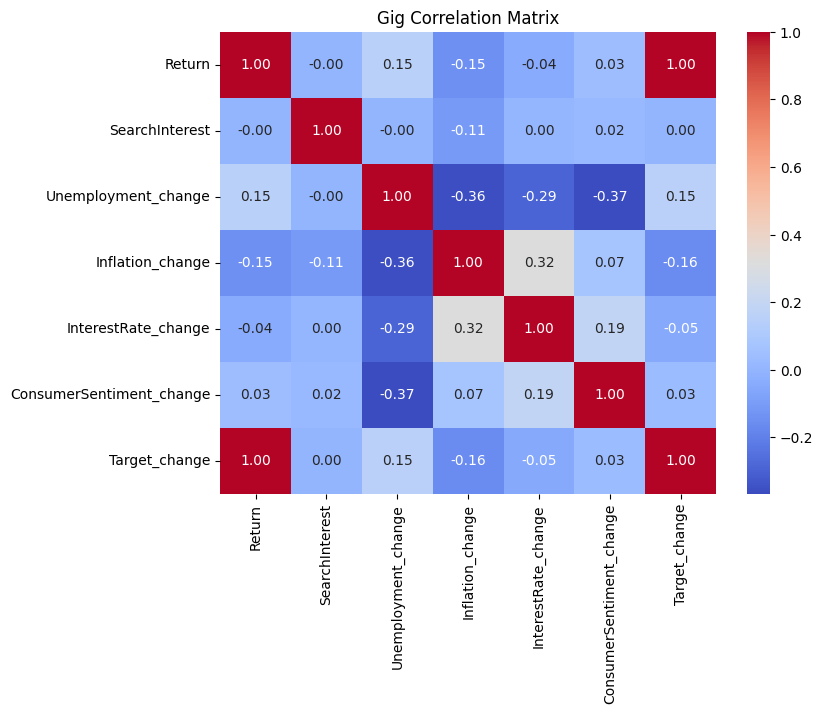

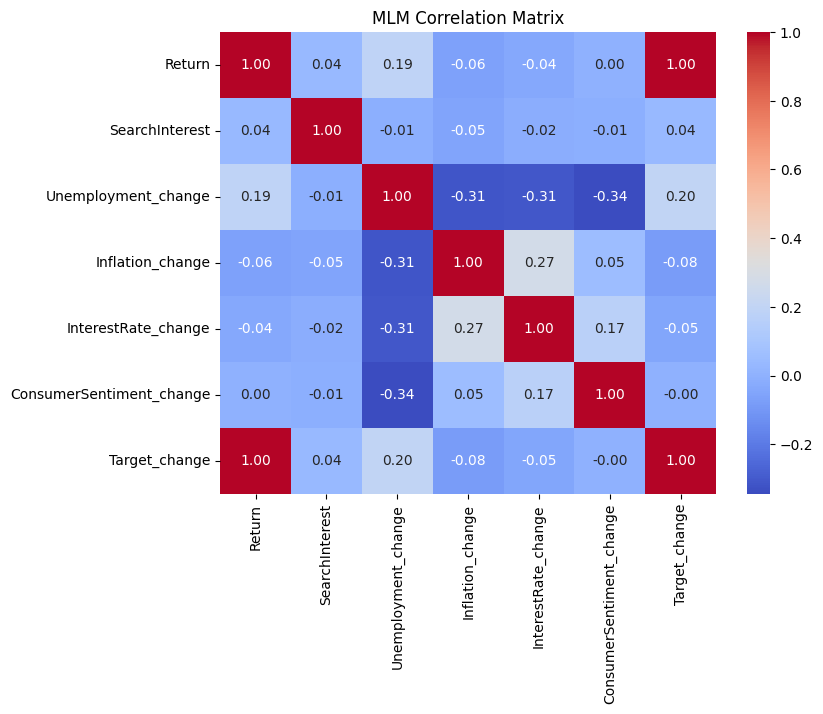

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------
# Set up Groups
groups = ['Gig', 'MLM']
# -------------------------------
# Adjust column names to match your dataset
cols_to_corr = [
    'Return',
    'SearchInterest',
    'Unemployment_change',
    'Inflation_change',
    'InterestRate_change',
    'ConsumerSentiment_change',
    'Target_change'
]
# -------------------------------
# Compute correlation matrix
# -------------------------------
for g in groups:
  temp=df[df['CompanyType']== g]
  corr=temp[cols_to_corr].dropna().corr() # remove rows with missing values


# -------------------------------
# Plot heatmap
# -------------------------------
  plt.figure(figsize=(8,6))
  sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
  plt.title(f"{g} Correlation Matrix")
  plt.show()

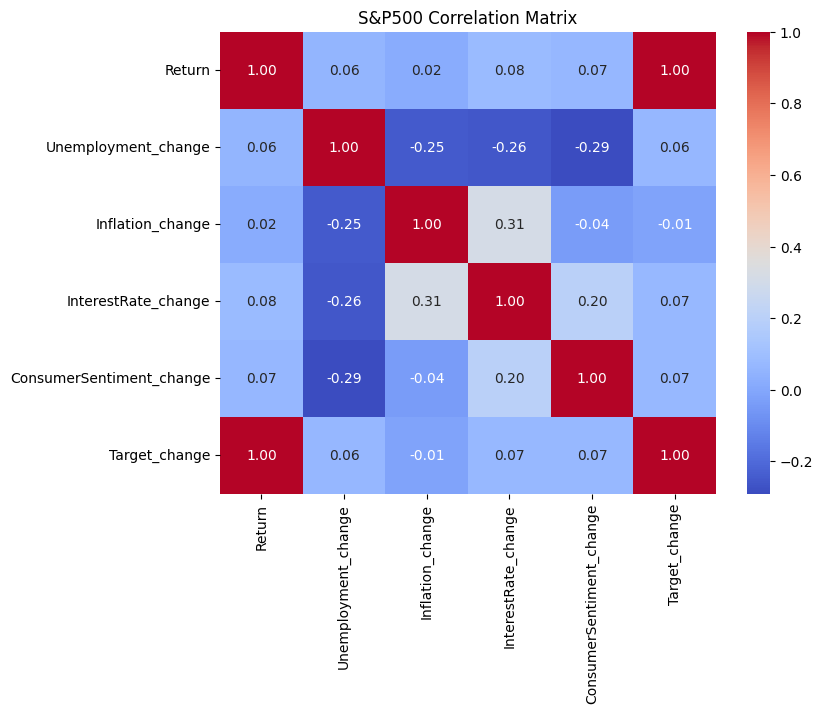

In [49]:
# -------------------------------
# Set up Groups
groups = ['SP500']
# -------------------------------
# Adjust column names to match your dataset
cols_to_corr = [
    'Return',
    'Unemployment_change',
    'Inflation_change',
    'InterestRate_change',
    'ConsumerSentiment_change',
    'Target_change'
]
# -------------------------------
# Compute correlation matrix
# -------------------------------
for g in groups:
  temp=df[df['CompanyType']== g]
  corr=temp[cols_to_corr].dropna().corr() # remove rows with missing values


# -------------------------------
# Plot heatmap
# -------------------------------
  plt.figure(figsize=(8,6))
  sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
  plt.title("S&P500 Correlation Matrix")
  plt.show()

In [50]:
gig_df = df[df['CompanyType'] == 'Gig']
MLM_df = df[df['CompanyType'] == 'MLM']
SP500_df = df[df['CompanyType'] == 'SP500']

SP500_df.head()

,year,month,company,Close,SearchInterest,cpi_inflation_data_annual,unemployment_data_monthly,cpi_data_monthly,rec_smooth_prob_data_monthly,rec_nber_data_monthly,...,target,Return,Target_change,Search_change,Inflation_change,Unemployment_change,InterestRate_change,ConsumerSentiment_change,CompanyType,EconomicStress
1670,2005,1,3M,38.180622,NaN,3.392747,5.3,191.6,0.06,0.0,...,0.199273,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SP500,False
1671,2005,2,3M,38.181286,NaN,3.392747,5.4,192.4,0.12,0.0,...,0.198447,0.000017,-0.004141,NaN,0.004175,0.1,0.22,-1.4,SP500,False
1672,2005,3,3M,38.977291,NaN,3.392747,5.2,193.1,0.42,0.0,...,0.201850,0.020848,0.017147,NaN,0.003638,-0.2,0.13,-1.5,SP500,False
1673,2005,4,3M,34.783459,NaN,3.392747,5.2,193.7,0.18,0.0,...,0.179574,-0.107597,-0.110361,NaN,0.003107,0.0,0.16,-4.9,SP500,False
1674,2005,5,3M,35.056538,NaN,3.392747,5.1,193.6,0.22,0.0,...,0.181077,0.007851,0.008371,NaN,-0.000516,-0.1,0.21,-0.8,SP500,False


# Economic Stress Analysis

<Axes: xlabel='EconomicStress', ylabel='Return'>

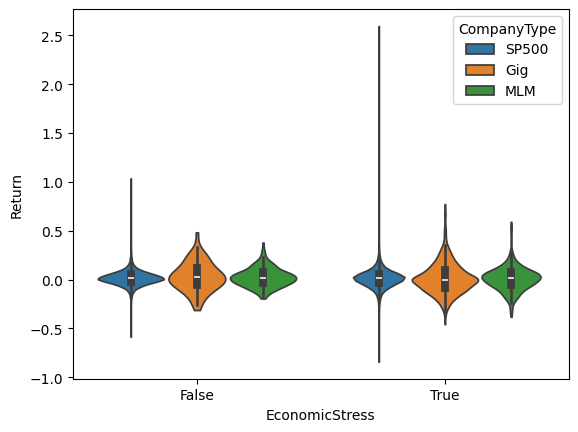

In [51]:
#sns.boxplot(x='EconomicStress', y='Return', data=gig_df)
#sns.boxplot(x='EconomicStress', y='Return', data=sp500_df)
sns.violinplot(x='EconomicStress', y='Return', hue='CompanyType', data=df, cut=0)
#plt.ylim(-0.3, 0.3)

In [52]:
from scipy.stats import ttest_ind

stress_returns = df[df['EconomicStress'] == True]['Return']
nonstress_returns = df[df['EconomicStress'] == False]['Return']

ttest_ind(stress_returns.dropna(), nonstress_returns.dropna())

TtestResult(statistic=np.float64(-4.033091165756772), pvalue=np.float64(5.508307835093204e-05), df=np.float64(116035.0))

In [53]:
# Gig companies
gig_stress = df[(df['CompanyType']=='Gig') & (df['EconomicStress']==True)]['Return']
gig_nonstress = df[(df['CompanyType']=='Gig') & (df['EconomicStress']==False)]['Return']

ttest_ind(gig_stress.dropna(), gig_nonstress.dropna())


TtestResult(statistic=np.float64(-0.7795305817096759), pvalue=np.float64(0.43589951600002597), df=np.float64(794.0))

In [54]:
# MLM companies
gig_stress = df[(df['CompanyType']=='MLM') & (df['EconomicStress']==True)]['Return']
gig_nonstress = df[(df['CompanyType']=='MLM') & (df['EconomicStress']==False)]['Return']

ttest_ind(gig_stress.dropna(), gig_nonstress.dropna())

TtestResult(statistic=np.float64(-1.4208806504840803), pvalue=np.float64(0.1558045147394047), df=np.float64(688.0))

In [55]:
# S&P500
sp_stress = df[(df['CompanyType']=='SP500') & (df['EconomicStress']==True)]['Return']
sp_nonstress = df[(df['CompanyType']=='SP500') & (df['EconomicStress']==False)]['Return']

ttest_ind(sp_stress.dropna(), sp_nonstress.dropna())

TtestResult(statistic=np.float64(-3.9003833553017824), pvalue=np.float64(9.60952535141767e-05), df=np.float64(114549.0))

# CCF: Lag Analysis - Search Interest & Stock Price

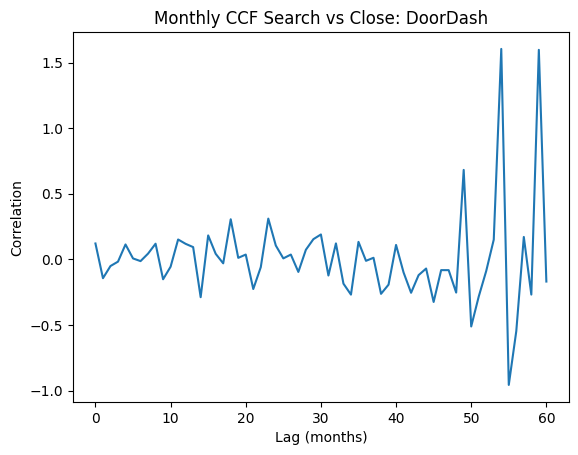

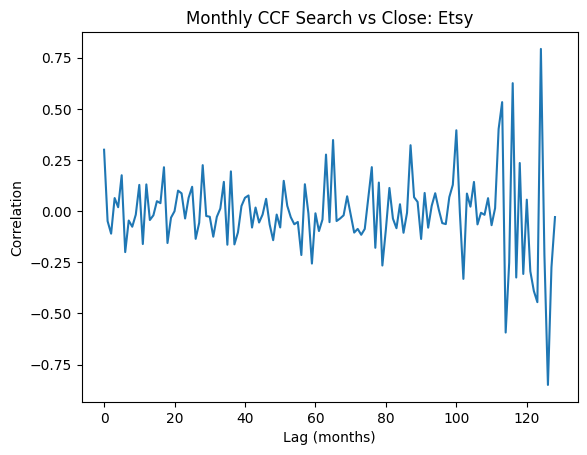

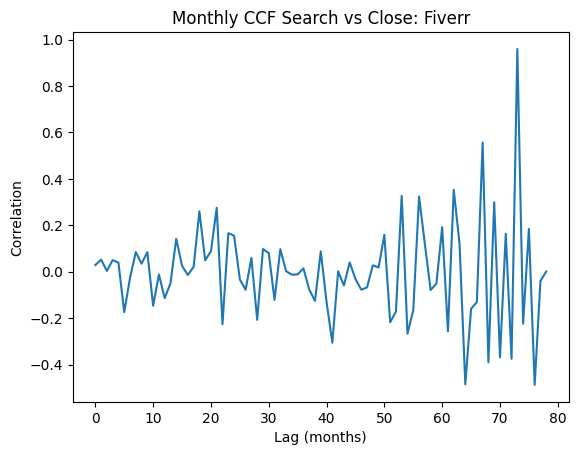

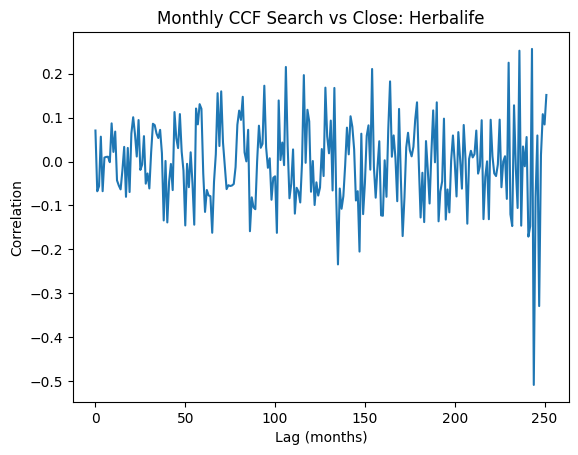

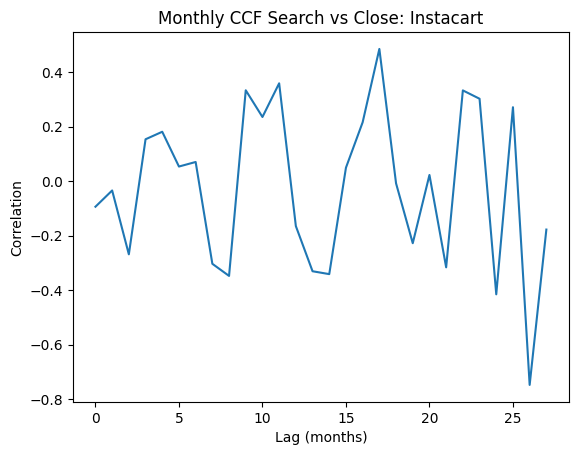

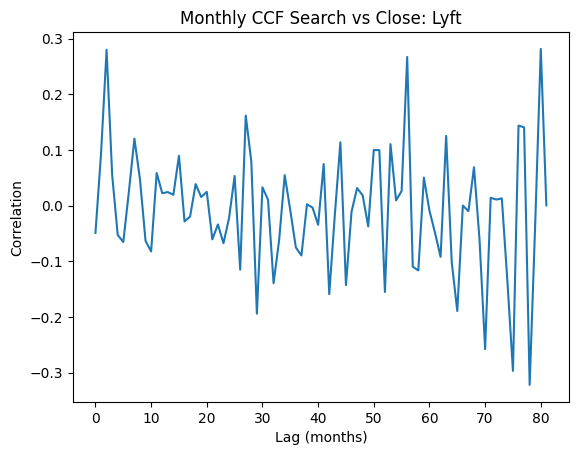

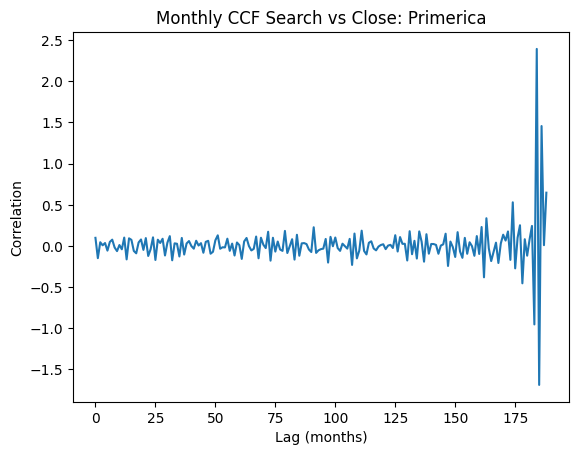

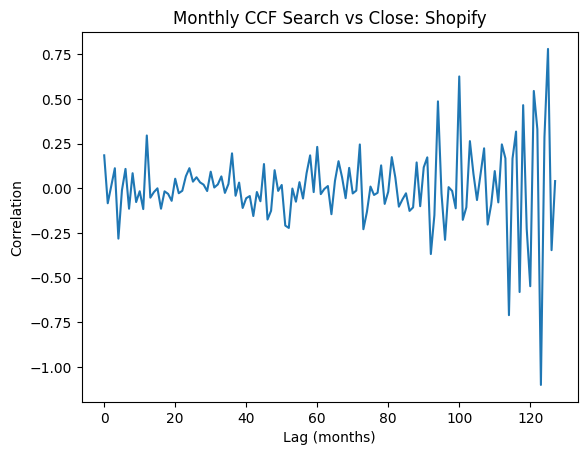

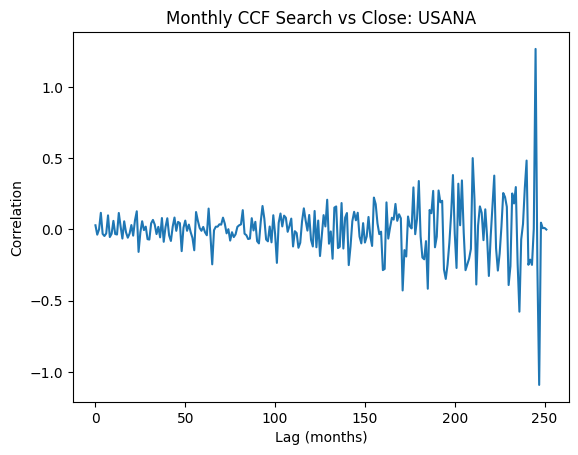

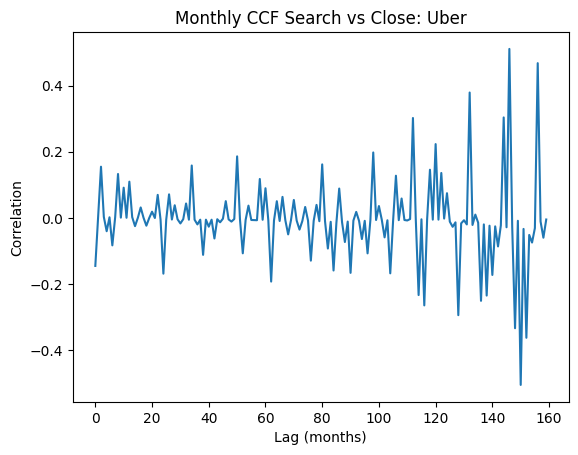

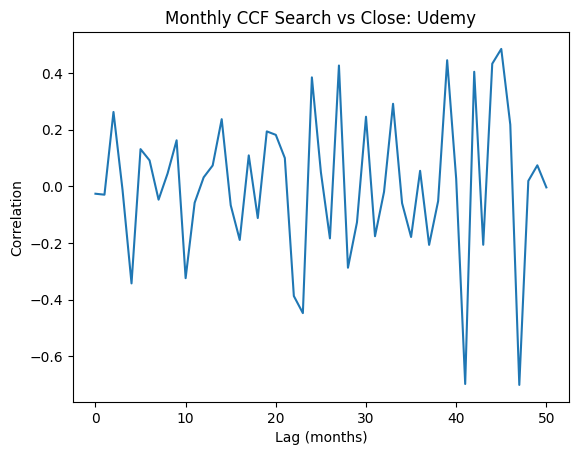

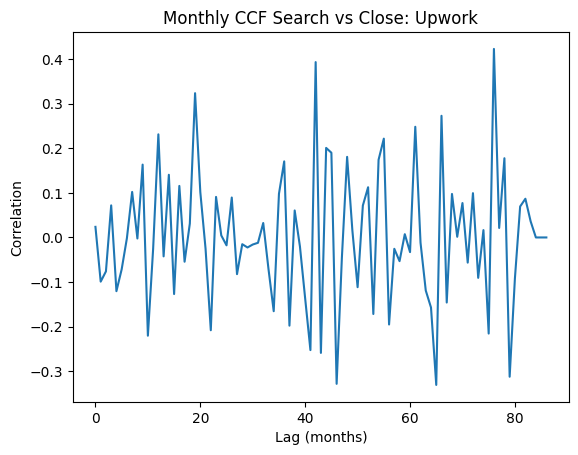

In [57]:
from statsmodels.tsa.stattools import ccf
import matplotlib.pyplot as plt

# monthly
companies = df['company'].unique()

for c in companies:
    temp = df[df['company'] == c].copy()

    temp = temp.sort_values(['year', 'month'])

    # create time index
    temp['date'] = pd.to_datetime(temp[['year','month']].assign(day=1))
    temp = temp.set_index('date')


    if temp['SearchInterest'].notna().sum() > 10:
        x = temp['SearchInterest'].diff().fillna(0)
        y = temp['Close'].pct_change().fillna(0)

        ccf_vals = ccf(x, y)

        plt.plot(ccf_vals)
        plt.title(f'Monthly CCF Search vs Close: {c}')
        plt.xlabel('Lag (months)')
        plt.ylabel('Correlation')
        plt.show()